## 1. Load Data

In [6]:
pip -q install folktables fairlearn cleanlab scikit-learn pandas matplotlib seaborn

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from IPython.display import display
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss,
    brier_score_loss, confusion_matrix, precision_score, recall_score,
)

from fairlearn.metrics import (
    MetricFrame, selection_rate, count, true_positive_rate,
    false_positive_rate, demographic_parity_difference,
    demographic_parity_ratio, equalized_odds_difference,
    equalized_odds_ratio,
)

RANDOM_STATE = 42
STATE = "CA"
MAX_SAMPLES = 50_000

In [8]:
from fairlearn.datasets import fetch_bank_marketing
import pandas as pd
import numpy as np

bunch = fetch_bank_marketing(as_frame=True)
df = bunch.frame
print(df.shape)
display(df.head())
print(df.columns)
print(df["Class"].value_counts(normalize=True))

(45211, 17)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')
Class
1    0.883015
2    0.116985
Name: proportion, dtype: float64


- There are 45.211 observations each with 17 features
- 88 % of the observations said no to the term deposit

In [9]:
column_mapping = {
    "V1": "age",
    "V2": "job",
    "V3": "marital",
    "V4": "education",
    "V5": "default",
    "V6": "balance",
    "V7": "housing",
    "V8": "loan",
    "V9": "contact",
    "V10": "day",
    "V11": "month",
    "V12": "duration",
    "V13": "campaign",
    "V14": "pdays",
    "V15": "previous",
    "V16": "poutcome",
    "Class": "y",
}

df = df.rename(columns=column_mapping)
display(df.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [10]:
print(df["education"].unique())

['tertiary', 'secondary', 'unknown', 'primary']
Categories (4, object): ['primary', 'secondary', 'tertiary', 'unknown']


In [11]:
# Load and rename columns (from earlier)
bunch = fetch_bank_marketing(as_frame=True)
df = bunch.frame.rename(columns=column_mapping)

y_reference = (df["y"] == "2").astype(int).reset_index(drop=True)  # '2' = yes (confirmed via value_counts)

education_group = df["education"].reset_index(drop=True)

X_all = df.drop(columns=["y"]).reset_index(drop=True)

idx = np.arange(len(X_all))
strata = y_reference.astype(str) + "_" + education_group.astype(str)

train_idx, temp_idx = train_test_split(
    idx, test_size=.40, random_state=RANDOM_STATE, stratify=strata
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=.50, random_state=RANDOM_STATE,
    stratify=strata.iloc[temp_idx],
)

def take(x, ids):
    return x.iloc[ids].reset_index(drop=True)

X_train, X_val, X_test = [take(X_all, z) for z in (train_idx, val_idx, test_idx)]
y_train, y_val, y_test = [take(y_reference, z) for z in (train_idx, val_idx, test_idx)]
A_train, A_val, A_test = [take(education_group, z) for z in (train_idx, val_idx, test_idx)]

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n": [len(X_train), len(X_val), len(X_test)],
    "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
}))

for split_name, A_split in [("train", A_train), ("validation", A_val), ("test", A_test)]:
    print(f"\n{split_name} education distribution:")
    print(A_split.value_counts(normalize=True))

,split,n,positive_rate
0,train,27126,0.116973
1,validation,9042,0.117010
2,test,9043,0.116997



train education distribution:
education
secondary    0.513198
tertiary     0.294183
primary      0.151552
unknown      0.041068
Name: proportion, dtype: float64

validation education distribution:
education
secondary    0.513161
tertiary     0.294183
primary      0.151515
unknown      0.041141
Name: proportion, dtype: float64

test education distribution:
education
secondary    0.513215
tertiary     0.294261
primary      0.151498
unknown      0.041026
Name: proportion, dtype: float64


- We see the education level is distributed not equally but similarly between the train, validation and test sets

##2. Fit a transparent baseline

We retain `EDUCATION` for the first model. (Later, compare a model that excludes them.)

**Removing a sensitive attribute does not remove proxies and is not itself a fairness guarantee** - We discuss this in lecture

In [12]:
NUMERIC = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

def make_model(frame, C=1.0):
    numeric = [c for c in NUMERIC if c in frame.columns]
    categorical = [c for c in frame.columns if c not in numeric]
    prep = ColumnTransformer([
        ("num", StandardScaler(), numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ])

    return Pipeline([
        ("preprocess", prep),
        ("model", LogisticRegression(max_iter=1000, C=C)),
    ])

FEATURES = list(X_train.columns)
model = make_model(X_train[FEATURES])
model.fit(X_train[FEATURES], y_train)
val_score = model.predict_proba(X_val[FEATURES])[:, 1]
val_pred = (val_score >= .50).astype(int)

## 3. Metric families

| Family | Examples | Question | Important limitation |
|---|---|---|---|
| Performance | Accuracy, balanced accuracy, AUROC, log loss | Does the model work overall? | Can conceal subgroup failures |
| Independence | Selection rate, demographic parity difference/ratio | Are decisions distributed similarly? | Ignores the reference outcome |
| Separation | TPR/FPR, equal opportunity, equalized odds | Are errors similar conditional on $Y$? | Depends directly on label validity |
| Sufficiency | PPV/NPV | Does a decision mean the same thing across groups? | Threshold-dependent and unstable in small groups |

There is no universally correct fairness metric. The choice depends on the decision, harms, label-generating process, and deployment context.

Read the documentation of fairlearn.metrics and sklearn.metrics to identify the performance measures needed to assess Independence, Separation (Equalized Odds), Equal Opportunity, and Sufficiency. Add them to the analysis of the classifier as illustrated above, and create fairness diagnostics metrics that consider a ratio of metrics for the groups at hand, in a way that is consistent with each of the fairness criteria.

If you apply the standard practice of "more than 20% discrepancy is a problem" -- which combinations of datasets and fairness criteria lead to a conclusion of problematic bias?

In [13]:
def false_positive_rate_metric(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    return fp / (fp + tn) if (fp + tn) > 0 else np.nan

def true_negative_rate_metric(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tn / (tn + fp) if (tn + fp) > 0 else np.nan

def negative_predictive_value_metric(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tn / (tn + fn) if (tn + fn) > 0 else np.nan


metrics = {
    "n": count,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "selection_rate": selection_rate,
    "TPR_recall": recall_score,
    "FPR": false_positive_rate_metric,
    "PPV_precision": lambda y, p: precision_score(y, p, zero_division=0),
    "NPV": negative_predictive_value_metric,
    "TNR": true_negative_rate_metric,
}

mf = MetricFrame(metrics=metrics, y_true=y_val, y_pred=val_pred, sensitive_features=A_val)

print("Overall threshold metrics")
display(pd.Series(mf.overall))
print("By group")
display(mf.by_group)
print("Maximum minus minimum")
display(pd.Series(mf.difference(method="between_groups")))
print("Minimum divided by maximum")
display(pd.Series(mf.ratio(method="between_groups")))

diffs = mf.difference(method="between_groups")
ratios = mf.ratio(method="between_groups")

fairness_summary = pd.Series({
    "demographic_parity_difference": diffs["selection_rate"],
    "demographic_parity_ratio": ratios["selection_rate"],
    "equalized_odds_difference": max(diffs["TPR_recall"], diffs["FPR"]),
    "equalized_odds_ratio": min(ratios["TPR_recall"], ratios["FPR"]),
})
display(fairness_summary)

Overall threshold metrics


,0
n,9042.000000
accuracy,0.902234
balanced_accuracy,0.656434
selection_rate,0.059279
TPR_recall,0.335539
FPR,0.022670
PPV_precision,0.662313
NPV,0.917352
TNR,0.977330


By group


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
education,,,,,,,,,
primary,1370.0,0.923358,0.635681,0.040146,0.288136,0.016773,0.618182,0.936122,0.983227
secondary,4640.0,0.914224,0.654173,0.048707,0.324490,0.016145,0.703540,0.925011,0.983855
tertiary,2660.0,0.873684,0.664603,0.086090,0.365915,0.036709,0.637555,0.895928,0.963291
unknown,372.0,0.879032,0.641286,0.069892,0.313725,0.031153,0.615385,0.898844,0.968847


Maximum minus minimum


,0
n,4268.000000
accuracy,0.049673
balanced_accuracy,0.028921
selection_rate,0.045944
TPR_recall,0.077779
FPR,0.020565
PPV_precision,0.088155
NPV,0.040194
TNR,0.020565


Minimum divided by maximum


,0
n,0.080172
accuracy,0.946203
balanced_accuracy,0.956483
selection_rate,0.466325
TPR_recall,0.787439
FPR,0.439794
PPV_precision,0.874698
NPV,0.957063
TNR,0.979098


,0
demographic_parity_difference,0.045944
demographic_parity_ratio,0.466325
equalized_odds_difference,0.077779
equalized_odds_ratio,0.439794


- It should be noted the values in the final table with demographic difference and equalized odds etc.can be extracted from the tables that precede it

From the above tables we observe:

**Independence**:
- We see a disrepancy of ~54 % between the group with highest selection rate(tertiary) and group with lowest selection rate(primary)

**Separation**:
- We see a disrepancy of ~56 % which is based on the FPR with tertiary having the highest and secondayr having the lowest(but comparable to primary)


**Sufficiency**:






In [14]:
#raise NotImplementedError("TODO: calculate the overall probability metrics")
overall_probability_metrics = pd.Series({
    "ROC_AUC": roc_auc_score(y_val, val_score),
    "log_loss": log_loss(y_val, val_score)
})
display(overall_probability_metrics)
display(overall_probability_metrics)

prob_rows = []
for g in A_val.unique():
    m = A_val.eq(g).to_numpy()
    prob_rows.append({
        "group": g, "n": m.sum(),
        "ROC_AUC": roc_auc_score(y_val[m], val_score[m]),
        "log_loss": log_loss(y_val[m], val_score[m])
    })
display(pd.DataFrame(prob_rows).set_index("group"))

,0
ROC_AUC,0.905549
log_loss,0.244814


,0
ROC_AUC,0.905549
log_loss,0.244814


,n,ROC_AUC,log_loss
group,,,
secondary,4640,0.902511,0.224099
primary,1370,0.919586,0.198131
tertiary,2660,0.900769,0.299039
unknown,372,0.897257,0.287398


- For ROCAUC the performance are comparable across education level
- Model is better calibrated for primary and secondary, pointing that tertiary are probably overestimated to subscribe. In toher words we cant trust the model the least when evaluating tertiary

### Interpretation checkpoint

Think:

1. Which group has the higher selection rate, and by how much?
2. Which group has the higher FPR and which has the higher TPR?
3. Does the direction of the PPV gap match the direction of the selection-rate gap?
4. What can you **not** conclude from these numbers alone?

**Optional: Write down your interpretation**
1. Selection rate comparison: ...
2. FPR/TPR comparison: ...
3. PPV gap vs. selection-rate gap: ...
4. What you cannot conclude: ...

## 4. Thresholds change decisions, not score quality

Inspect a threshold sweep. A fairness conclusion based on one arbitrary threshold is incomplete.

,threshold,accuracy,selection_gap,TPR_gap,FPR_gap
0,0.10,0.822495,0.174778,0.164174,0.136442
1,0.15,0.869056,0.114898,0.093717,0.080604
2,0.20,0.888188,0.094545,0.110085,0.070218
3,0.25,0.894935,0.082494,0.109617,0.056478
4,0.30,0.900575,0.082869,0.179687,0.045575
5,0.35,0.902234,0.067301,0.139947,0.031878
6,0.40,0.902345,0.057618,0.113695,0.024756
7,0.45,0.901792,0.052843,0.083981,0.024531
8,0.50,0.902234,0.045944,0.077779,0.020565
9,0.55,0.900686,0.042053,0.081602,0.018311


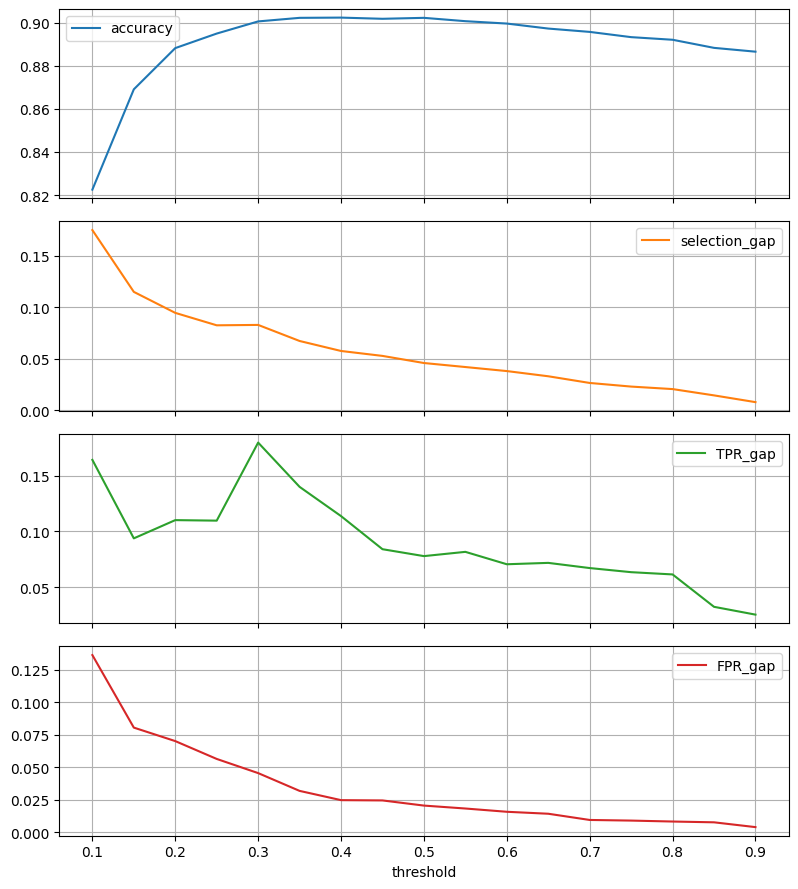

In [15]:
rows = []
for threshold in np.linspace(.1, .9, 17):
    pred = (val_score >= threshold).astype(int)
    frame = MetricFrame(
        metrics={"selection": selection_rate, "TPR": recall_score, "FPR": false_positive_rate_metric},
        y_true=y_val, y_pred=pred, sensitive_features=A_val,
    )
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, pred),
        "selection_gap": frame.difference()["selection"],
        "TPR_gap": frame.difference()["TPR"],
        "FPR_gap": frame.difference()["FPR"],
    })
sweep = pd.DataFrame(rows)
display(sweep)
sweep.set_index("threshold").plot(subplots=True, figsize=(8,9), grid=True)
plt.tight_layout()

## 5. Sensitive-feature removal and intersectional audit

Complete both tasks. Report group-specific values and subgroup counts, not only gaps.

Removing sensitive-feature solve the problem? What are other short-comings you can think of?

In [17]:
# TODO 1: fit a second model after removing education from predictive features.
# Retain A_val for auditing.
FEATURES_WITHOUT_A = [c for c in FEATURES if c not in ["education"]]

model_without_a = make_model(X_train[FEATURES_WITHOUT_A])
model_without_a.fit(X_train[FEATURES_WITHOUT_A], y_train)
score_without_a = model_without_a.predict_proba(X_val[FEATURES_WITHOUT_A])[:, 1]
pred_without_a = (score_without_a >= .50).astype(int)

In [20]:
mf_without_a = MetricFrame(
    metrics=metrics,
    y_true=y_val,
    y_pred=pred_without_a,
    sensitive_features=A_val,
)

print("Overall threshold metrics (model without education)")
display(pd.Series(mf_without_a.overall))
print("By group (model without education)")
display(mf_without_a.by_group)
print("Maximum minus minimum (model without education)")
display(pd.Series(mf_without_a.difference(method="between_groups")))
print("Minimum divided by maximum (model without education)")
display(pd.Series(mf_without_a.ratio(method="between_groups")))

Overall threshold metrics (model without education)


,0
n,9042.000000
accuracy,0.902345
balanced_accuracy,0.657317
selection_rate,0.059611
TPR_recall,0.337429
FPR,0.022796
PPV_precision,0.662338
NPV,0.917559
TNR,0.977204


By group (model without education)


,n,accuracy,balanced_accuracy,selection_rate,TPR_recall,FPR,PPV_precision,NPV,TNR
education,,,,,,,,,
primary,1370.0,0.926277,0.652630,0.043066,0.322034,0.016773,0.644068,0.938978,0.983227
secondary,4640.0,0.913362,0.655491,0.050431,0.328571,0.017590,0.688034,0.925329,0.982410
tertiary,2660.0,0.873684,0.660475,0.083083,0.355890,0.034940,0.642534,0.894629,0.965060
unknown,372.0,0.881720,0.642844,0.067204,0.313725,0.028037,0.640000,0.899135,0.971963


Maximum minus minimum (model without education)


,0
n,4268.000000
accuracy,0.052593
balanced_accuracy,0.017631
selection_rate,0.040017
TPR_recall,0.042164
FPR,0.018167
PPV_precision,0.048034
NPV,0.044349
TNR,0.018167


Minimum divided by maximum (model without education)


,0
n,0.080172
accuracy,0.943221
balanced_accuracy,0.973306
selection_rate,0.518347
TPR_recall,0.881524
FPR,0.480052
PPV_precision,0.930186
NPV,0.952769
TNR,0.981523


## Task 2: Perform fairness auditing on a marketing campaign dataset

Repeat the analysis on a new dataset - https://fairlearn.org/v0.13/api_reference/generated/fairlearn.datasets.fetch_bank_marketing.html

What do you learn about bias diagnostic? How are these metrics different?

## 📝 Project 1 Submission Guidelines

**Format:** Project 1 will be submitted as an **A0 Poster**.

**Week 1 Contribution:**
The findings and discussions generated from this Week 1 notebook should form the foundation of your project and cover approximately **1/3 of your final poster**.

When preparing your poster, ensure that this section includes:
* Clearly outline the context, goals, and intended real-world impact of the model.
* Explain what the different fairness metrics represent in the context of this specific use case (e.g., what does a disparity in False Positive Rate mean for the individuals actually affected?).
* Provide a short analysis of the bias present in the ACSIncome dataset and Bank Marketing dataset - from your exploratory data analysis and the fairness metric evaluations conducted in this notebook.